In [329]:
from prepare_output_file import collect_json_files
from utils import load_json, save_json, dialogue_to_string, extract_dialogue
from tqdm import tqdm
import dotenv

In [330]:
dev_predictions = collect_json_files("experiment_fs/output_dev/")
dev_truth = load_json("data/source/mrbench_v3_devset.json")

In [331]:
dev_predictions_ids = [i['conversation_id'] for i in dev_predictions]

In [332]:
target_ids = dev_predictions_ids[0]

yh = [p for p in dev_predictions if p['conversation_id'] == target_ids][0]
y = [truth for truth in dev_truth if truth['conversation_id'] == target_ids][0]

print(target_ids)

3530-162a5d8e-7b1a-4e4d-b26e-8b6b70c3d8eb


In [333]:
dialogue = dialogue_to_string(extract_dialogue(y["conversation_history"]))
print(dialogue)

- Tutor: Hi, could you please provide a step-by-step solution for the question below? The question is: Four classmates were comparing their ages based on their birth month. They found out that Jolyn is 2 months older than Therese while Therese is 5 months older than Aivo. Then, Leon is 2 months older than Aivo. How much older in months is Jolyn than Leon?
- Student: We can start by creating a diagram to visualize the relationships between the classmates' ages:

Aivo --(5 months)--> Therese --(2 months)--> Jolyn
|
(2 months)
|
Leon

From the diagram, we can see that Jolyn is 2 + 5 = 7 months older than Aivo, and Leon is 2 months older than Aivo. Therefore, Jolyn is 7 + 2 = 9 months older than Leon.
 9
- Tutor: Can you talk me through your solution?
- Student: Sure. I started by creating a diagram to visualize the relationships between the classmates' ages. Aivo is 5 months older than Therese and Therese is 2 months older than Jolyn. Leon is 2 months older than Aivo. So Jolyn is 7 months

In [334]:
for tutor in y['tutor_responses']:
    response = y['tutor_responses'][tutor]['response']
    value = y['tutor_responses'][tutor]['annotation']['Mistake_Identification']
    predicted = yh['tutor_responses'][tutor]['annotation']['Mistake_Identification']
    print(f"--- {tutor} ---")
    print(f"response: {response}")
    print(f"Truth: {value}")
    print(f"Predicted: {predicted}")

    

--- Sonnet ---
response: You've done a great job creating a visual diagram, but let's take a closer look at the relationships between the ages to ensure we're interpreting them correctly.
Truth: Yes
Predicted: To some extent
--- Llama318B ---
response: I understand what you did, but to make it clearer, let's break down the steps and represent it in a simpler equation to calculate the age difference between Jolyn and Leon.
Truth: Yes
Predicted: No
--- Expert ---
response: A diagram to visualise the problem is a great idea. And you have made a good start, but you have made an error in one of the steps. Can you look over it again and see if you can spot where it is?
Truth: Yes
Predicted: To some extent
--- GPT4 ---
response: You've done a great job at visualizing the relationships between the classmates' ages. However, there seems to be a small mistake in your calculation. If Jolyn is 7 months older than Aivo and Leon is 2 months older than Aivo, it means Jolyn is actually 7 - 2 = 5 month

In [335]:
def evaluate_mistake_identification_f1_multiclass(gold_data, pred_data, mode='strict', average="macro"):
    y_true = []
    y_pred = []
    tutors = []
    instances = []

    label_mapping = {
        "yes": 0,
        "to some extent": 1,
        "no": 2
    }

    inverse_label_mapping = {v: k for k, v in label_mapping.items()}

    if mode != 'strict':
        label_mapping = {
        "yes": 0,
        "to some extent": 0,
        "no":1
        }


    pred_lookup = {item['conversation_id']: item for item in pred_data}

    for gold_item in gold_data:
        conv_id = gold_item['conversation_id']
        if conv_id not in pred_lookup:
            continue

        pred_item = pred_lookup[conv_id]

        for model_name, gold_response in gold_item['tutor_responses'].items():
            if model_name not in pred_item['tutor_responses']:
                continue

            pred_response = pred_item['tutor_responses'][model_name]

            gold_label = gold_response['annotation']['Mistake_Identification'].strip().lower()
            pred_label = pred_response['annotation']['Mistake_Identification'].strip().lower()

            if gold_label in label_mapping and pred_label in label_mapping:
                y_true.append(label_mapping[gold_label])
                y_pred.append(label_mapping[pred_label])
                tutors.append(model_name)
                instances.append({
                    'conversation_id': conv_id,
                    'model_name': model_name,
                    'gold_label': gold_label,
                    'pred_label': pred_label
                })

    if not y_true:
        print("No matching predictions found.")
        return 0.0
    return y_true, y_pred, tutors, instances

y_true, y_pred, tutors, instances = evaluate_mistake_identification_f1_multiclass(dev_truth, dev_predictions, average="macro")

In [336]:
label_mapping = {
    "yes": 0,
    "to some extent": 1,
    "no": 2
}

inverse_label_mapping = {v: k for k, v in label_mapping.items()}

tutors_evaluated = {}
filtered_instances = []

c = 0

for i,j,k in zip(y_true, y_pred, tutors):
    if i==0 and j== 1 and inverse_label_mapping[i] != inverse_label_mapping[j]:
        filtered_instances.append({
            'conversation_id': instances[c]['conversation_id'],
            'model_name': instances[c]['model_name'],
            'gold_label': inverse_label_mapping[i],
            'pred_label': inverse_label_mapping[j]
        })
        if k not in tutors_evaluated:
            tutors_evaluated[k] = [(inverse_label_mapping[i], inverse_label_mapping[j])]
        else:
            tutors_evaluated[k].append((inverse_label_mapping[i], inverse_label_mapping[j]))
    c += 1

In [337]:
tutors_evaluated

{'Llama318B': [('yes', 'to some extent'), ('yes', 'to some extent')],
 'Sonnet': [('yes', 'to some extent'), ('yes', 'to some extent')],
 'Expert': [('yes', 'to some extent'),
  ('yes', 'to some extent'),
  ('yes', 'to some extent')],
 'Mistral': [('yes', 'to some extent')],
 'Gemini': [('yes', 'to some extent')]}

In [338]:
# sort the instances by conversation_id
filtered_instances.sort(key=lambda x: x['conversation_id'])
filtered_instances

[{'conversation_id': '2270-e6cb34ce-4251-4d1b-9f80-28358033a287',
  'model_name': 'Expert',
  'gold_label': 'yes',
  'pred_label': 'to some extent'},
 {'conversation_id': '3110-bb76933b-3239-40f3-af66-b3a96517b1a3',
  'model_name': 'Llama318B',
  'gold_label': 'yes',
  'pred_label': 'to some extent'},
 {'conversation_id': '320-aa465d06-81e9-49bc-ab0e-becc061e4ca5',
  'model_name': 'Sonnet',
  'gold_label': 'yes',
  'pred_label': 'to some extent'},
 {'conversation_id': '320-aa465d06-81e9-49bc-ab0e-becc061e4ca5',
  'model_name': 'Gemini',
  'gold_label': 'yes',
  'pred_label': 'to some extent'},
 {'conversation_id': '3530-162a5d8e-7b1a-4e4d-b26e-8b6b70c3d8eb',
  'model_name': 'Sonnet',
  'gold_label': 'yes',
  'pred_label': 'to some extent'},
 {'conversation_id': '3530-162a5d8e-7b1a-4e4d-b26e-8b6b70c3d8eb',
  'model_name': 'Expert',
  'gold_label': 'yes',
  'pred_label': 'to some extent'},
 {'conversation_id': '3970-82bd1757-b4e7-4e5e-b870-01c01bd5a8bc',
  'model_name': 'Llama318B',
  'g

In [339]:
# classification report
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

def print_classification_report(y_true, y_pred):
    # Convert the lists to numpy arrays
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Print the classification report
    print(classification_report(y_true, y_pred, target_names=list(label_mapping.keys())))

# Print the classification report
print_classification_report(y_true, y_pred)

                precision    recall  f1-score   support

           yes       0.95      0.88      0.91        89
to some extent       0.15      0.25      0.19         8
            no       0.75      0.83      0.79        18

      accuracy                           0.83       115
     macro avg       0.62      0.65      0.63       115
  weighted avg       0.86      0.83      0.84       115



Confusion Matrix:


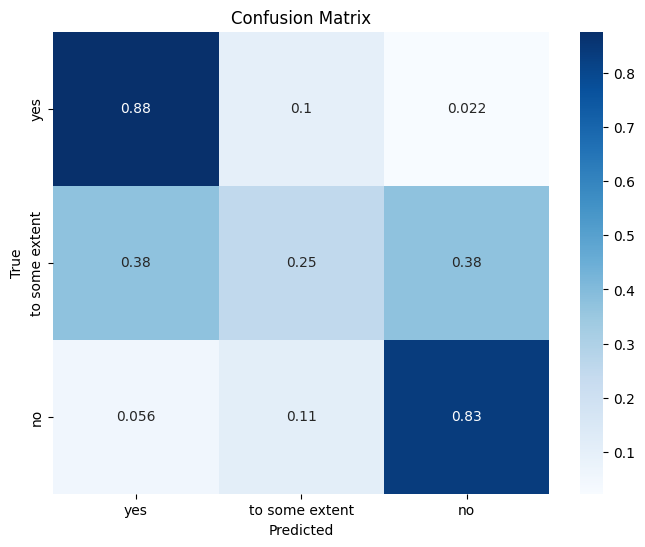

In [340]:
# plot cm matric

import matplotlib.pyplot as plt
import seaborn as sns

# Print the confusion matrix
cm = confusion_matrix(y_true, y_pred, normalize='true')
print("Confusion Matrix:")


def plot_confusion_matrix(cm, labels):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

# Plot the confusion matrix
plot_confusion_matrix(cm, list(label_mapping.keys()))

Confusion Matrix:


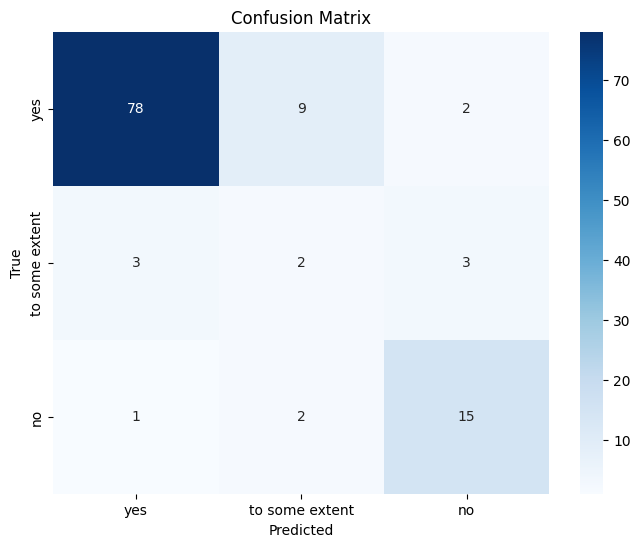

In [341]:
# plot cm matric

import matplotlib.pyplot as plt
import seaborn as sns

# Print the confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")


def plot_confusion_matrix(cm, labels):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

# Plot the confusion matrix
plot_confusion_matrix(cm, list(label_mapping.keys()))

In [342]:
cm

array([[78,  9,  2],
       [ 3,  2,  3],
       [ 1,  2, 15]])